In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import zarr
import os
import sys

from pathlib import Path

sys.path.append(os.path.abspath(".."))

plt.style.use('../libs/my_style.mplstyle')

input_dir = Path('/mnt/e/Sasaki/MTSingleBeads')

experiments = [
    "20260121/beads_trans_crop_crop",
    "20260121/exp_crop1",
    "20260122/exp",
    "20260122/exp001"
]

op_data = []
labels = []

i = 0

# データの読み込み
for exp_subpath in experiments:
    target_path = input_dir / exp_subpath / "MTs_order_parameter.zarr"
    
    if target_path.exists():
        try:
            op_zarr = zarr.open(str(target_path), mode='r')
            op = op_zarr[:]
            
            # NaNなどの無効な値を除外して1次元配列にする
            op = np.array(op).flatten()
            op = op[~np.isnan(op)]
            op_data.append(op)
            
            # ラベルに実験のサブパスを使用
            labels.append(f'exp{i}')
            
            num = len(op)
            op_mean = np.mean(op) if num > 0 else np.nan
            op_sem = np.std(op, ddof=1)/np.sqrt(num) if num > 1 else 0
            print(f"exp{i}: Mean = {op_mean:.4f}, SEM = {op_sem:.4f}, N = {num}")

            i+=1
            
        except Exception as e:
            print(f"Error loading {target_path}: {e}")
    else:
        print(f"Warning: {target_path} does not exist.")



exp0: Mean = 0.9753, SEM = 0.0007, N = 271
exp1: Mean = 0.9911, SEM = 0.0000, N = 491
exp2: Mean = 0.9719, SEM = 0.0010, N = 271
exp3: Mean = 0.9824, SEM = 0.0002, N = 501


/tmp/ipykernel_133296/1870631352.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(op_data, labels=labels, patch_artist=True)


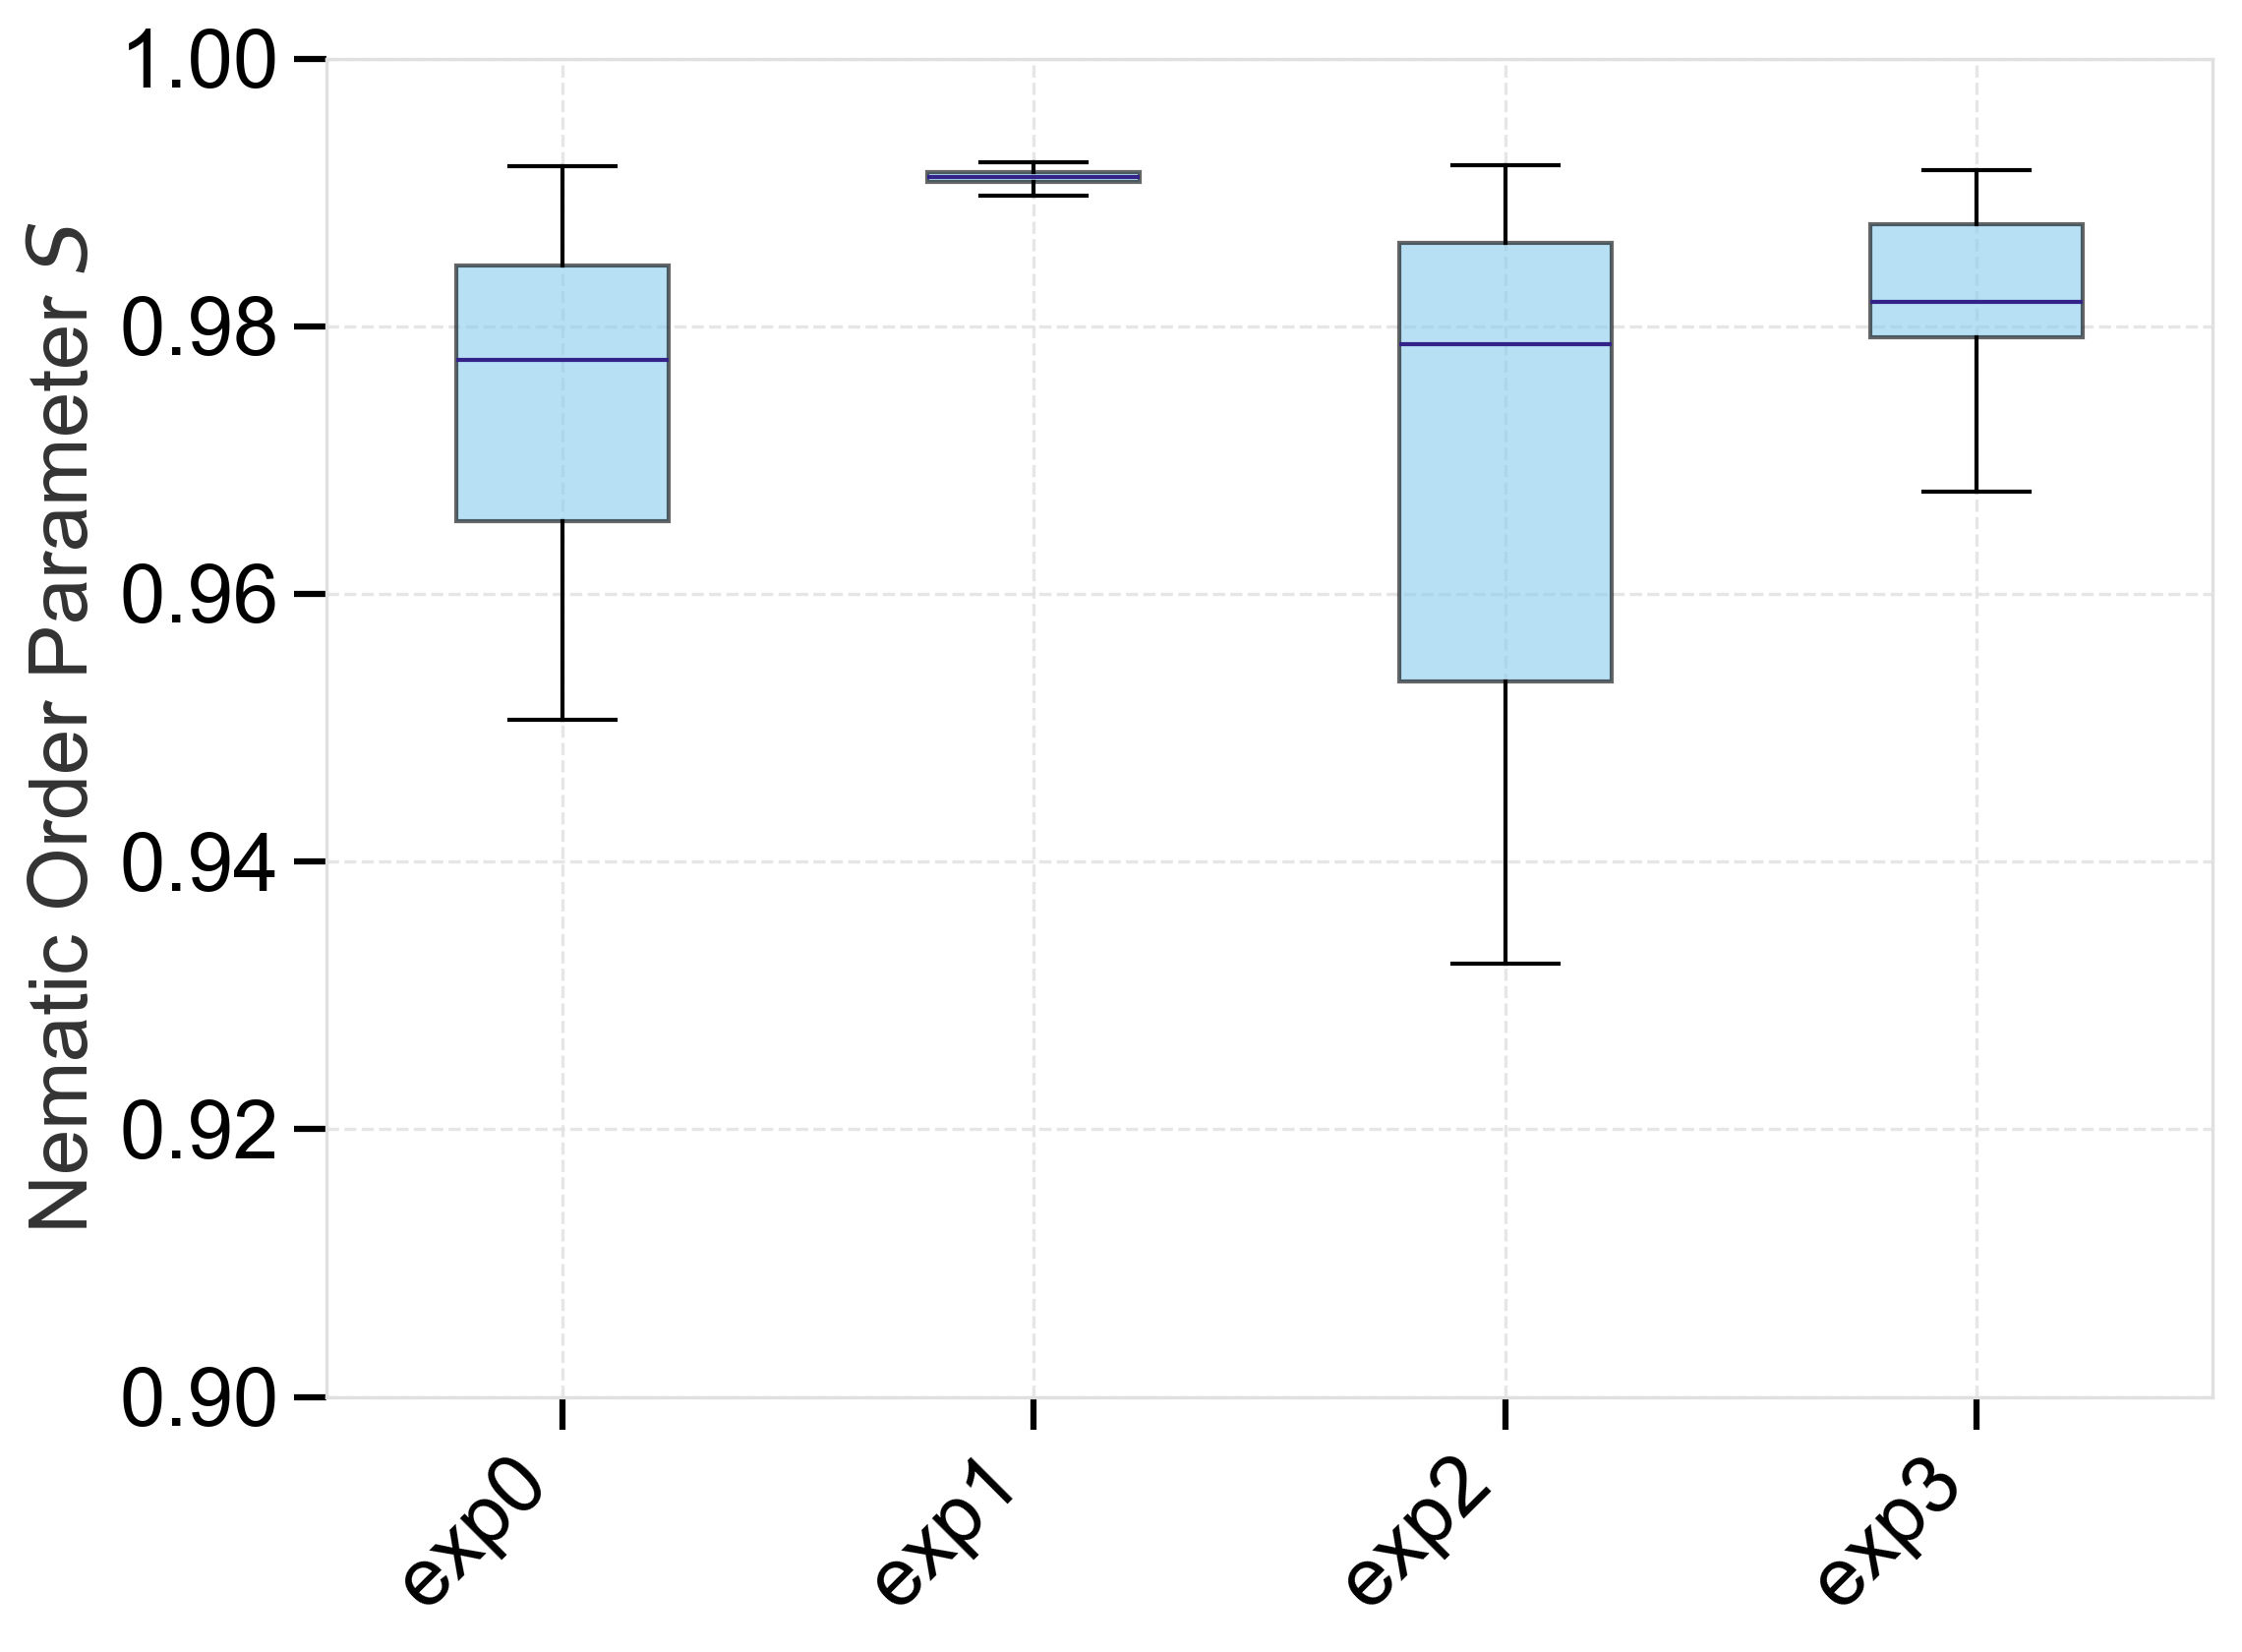

In [8]:
# 箱ひげ図の作成
if op_data:
    fig, ax = plt.subplots()
    
    # ボックスプロットを描画
    bp = ax.boxplot(op_data, labels=labels, patch_artist=True)
    
    # 見やすくするために色を付ける（オプション）
    for box in bp['boxes']:
        box.set(facecolor='#88CCEE', alpha=0.6)
        
    ax.set_ylabel("Nematic Order Parameter $S$")
    #ax.set_title("Order Parameter per Experiment")
    ax.set_ylim(0.9, 1.0)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    # 画像の保存
    #plt.savefig(args.output, dpi=300)
    #print(f"Saved boxplot to {args.output}")
else:
    print("No valid data available to plot.")